<a href="https://colab.research.google.com/github/sana-ai-learner/ML-Customer-Retail-Project/blob/main/lr_dt_knn_comaprison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv('customer_retail csv file.csv')

In [ ]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
df = df.dropna()

In [ ]:
df = df[['Quantity','UnitPrice','Country']]

In [ ]:
encoder = LabelEncoder()
df['Country']=encoder.fit_transform(df['Country'])

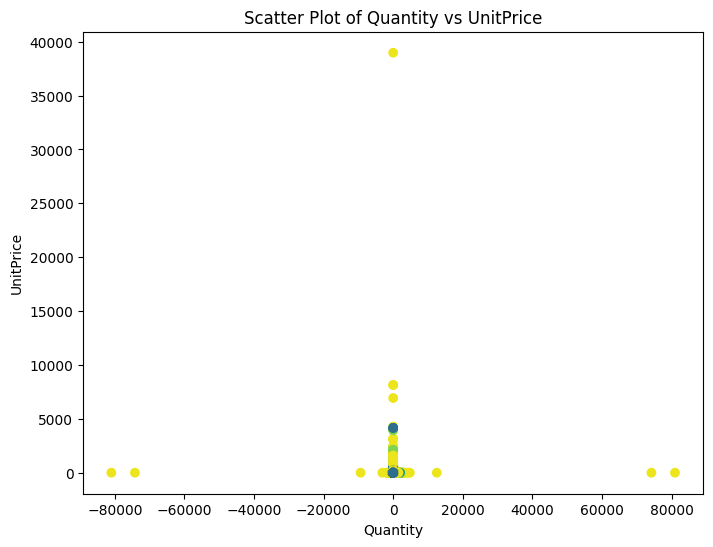

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Quantity'],df['UnitPrice'],c=df['Country'],cmap='viridis')
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()

In [ ]:
x = df[['Quantity','UnitPrice']]
y = df[['Country']]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



In [ ]:
print("Logistic Regression")
log_model = LogisticRegression()
log_model.fit(x_train,y_train)
y_pred = log_model.predict(x_test)
log_accuracy = accuracy_score(y_test,y_pred)
print("accuracy:",log_accuracy)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy: 0.8897451023769142
confusion matrix:
 [[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    7     0     0 ...     0 72395     0]
 [    0     0     0 ...     0    43     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Decision Tree")
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred = dt_model.predict(x_test)
dt_accuracy = accuracy_score(y_test,y_pred)
print("accuracy:",dt_accuracy)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)

Decision Tree
accuracy: 0.8903104490819261
confusion matrix:
 [[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   23     0     0 ...     1 72219     0]
 [    0     0     0 ...     0    43     0]]


In [ ]:
print("KNN")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train,y_train)
y_pred = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test,y_pred)
print("accuracy:",knn_accuracy)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)

KNN


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


accuracy: 0.8842268269301674
confusion matrix:
 [[   25     0     0 ...     0   181     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   41     2     0 ...     0 71636     0]
 [    0     0     0 ...     0    43     0]]


In [ ]:
models =['Logistic Regression',
         'Decision Tree',
         'KNN']

accuracy = [log_accuracy,
            dt_accuracy,
            knn_accuracy]

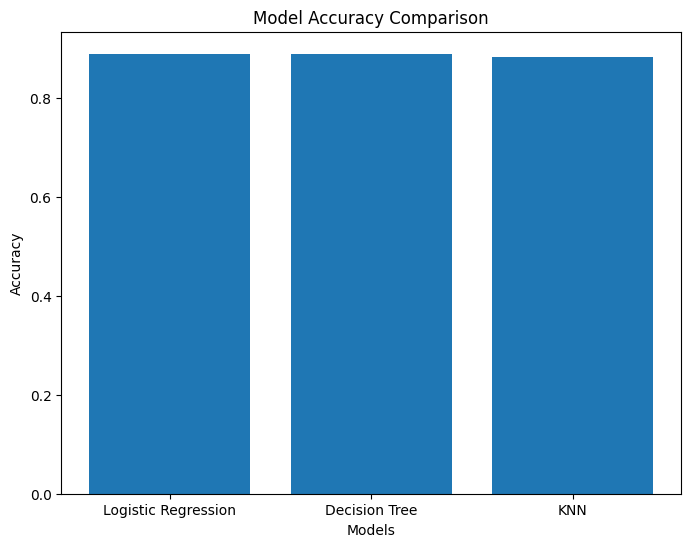

In [ ]:
plt.figure(figsize=(8,6))
plt.bar(models,accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()